Yasamin modabber 


student iD:97101059

Question1:

In [39]:
using Plots, DataFrames, Dates, CSV , Statistics
theme(:juno)

In [ ]:
#in python:
"""
import yfinance as yf
Data = pd.DataFrame()
tickerSymbol =["BTC-USD" , "ETH-USD" , "XRP-USD" , "SOL-USD" , "LUNA1-USD" , "ADA-USD" , "AVAX-USD" , "DOT-USD" , "DOGE-USD" , "MATIC-USD"]
n=0
for t in tickerSymbol:
    tickerData = yf.Ticker(tickerSymbol[n])
    Data[t] = tickerData.history(period='1d', start='2021-01-01', end='2022-01-01')['Close']
    n=n+1
Data.to_csv("Data_crypto.csv")
"""

In [40]:
#i got the data files from yahoo finance
df1=CSV.read("D:\\physics\\data science\\project 2\\Data_crypto.CSV",DataFrame) # start='2021-01-01', end='2022-01-01'

,Date,BTC-USD,ETH-USD,XRP-USD,SOL-USD,LUNA1-USD,ADA-USD,AVAX-USD
,Date,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,2020-12-31,29001.7,737.803,0.219846,1.5109,0.65252,0.181397,3.13561
2,2021-01-01,29374.2,730.368,0.237444,1.84208,0.649443,0.17535,3.66482
3,2021-01-02,32127.3,774.535,0.221655,1.79928,0.631426,0.177423,3.49494
4,2021-01-03,32782.0,975.508,0.225848,2.16175,0.661895,0.204995,3.47294
5,2021-01-04,31971.9,1040.23,0.236677,2.4851,0.670244,0.224762,3.59024
6,2021-01-05,33992.4,1100.01,0.22675,2.15722,0.716674,0.258314,4.23741
7,2021-01-06,36824.4,1207.11,0.250895,1.92922,0.716177,0.331898,4.62036
8,2021-01-07,39371.0,1225.68,0.326002,2.37275,0.859008,0.29998,4.47661
9,2021-01-08,40797.6,1224.2,0.32323,3.21989,0.852572,0.305597,5.79711


cumulaive return of Bitcoin: 0.5966792379843284
cumulaive return of Ethereum: 3.9913469953394918
cumulaive return of Ripple: 2.7806601297376923
cumulaive return of Solana: 111.71381187693447
cumulaive return of Terra: 129.9883860826643


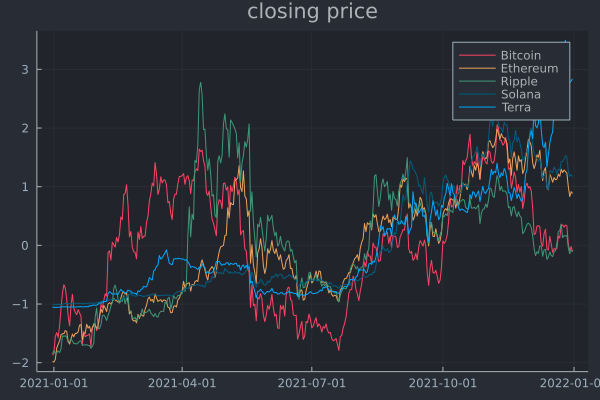

In [3]:
tickerSymbol =["BTC-USD" , "ETH-USD" , "XRP-USD" , "SOL-USD" , "LUNA1-USD" ] #top five cryptocurrencies (by market cap)
ticker=["Bitcoin","Ethereum","Ripple","Solana","Terra"]

df1.Dates = Date.(df1.Date)
df1.close = Float64.(df1[!, Symbol("BTC-USD")])

MEAN=[]
STD=[]
for i ∈1:5
    push!(STD,(Statistics.std(df1[!, Symbol(tickerSymbol[i])])))
    push!(MEAN,(Statistics.mean(df1[!, Symbol(tickerSymbol[i])])))
end

#plot
p=plot(df1.Dates, [(df1.close[j]-MEAN[1])/STD[1] for j in 1:size(df1)[1] ], label="Bitcoin", title = "closing price") 
for i ∈ 2:5
    df1.close = Float64.(df1[!, Symbol(tickerSymbol[i])])
    plot!(p,df1.Dates,[(df1.close[j]-MEAN[i])/STD[i] for j in 1:size(df1)[1] ], label=ticker[i])  
end

function Return(ticker) #Returns array contaning daily return
    return_ticker=[]
    for i in 2:size(df1)[1]
        push!(return_ticker,df1[i,Symbol(ticker)]/df1[i-1,Symbol(ticker)]-1)
    end 
    return return_ticker
end

function CumulativeReturn(ticker) #Returns array containing cumulative return
    CR=1
    for i in 2:size(df1)[1]
        CR*=(df1[i,Symbol(ticker)]/df1[i-1,Symbol(ticker)])
    end 
    return CR-1
end

for i ∈1:5
    println( "cumulaive return of $(ticker[i]): $(CumulativeReturn(tickerSymbol[i]))")
end
p

Based on the cumulative return of these five crypto currencies Terra (Luna) is the most profitable option.

Question2:

In [4]:
df2=CSV.read("D:\\physics\\data science\\project 2\\Data_crypto_6_month.CSV",DataFrame) #start='2021-11-01', end='2022-05-01'

,Date,BTC-USD,ETH-USD,XRP-USD,SOL-USD,LUNA1-USD,ADA-USD,AVAX-USD,DOT-USD
,Date,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64?
1,2021-10-31,61319.0,4288.07,1.11325,202.421,42.8898,1.96503,64.2878,42.7421
2,2021-11-01,61004.4,4324.63,1.09287,203.545,44.0593,1.95,65.0725,49.9823
3,2021-11-02,63226.4,4584.8,1.1362,220.24,44.7555,1.97138,67.5846,51.6314
4,2021-11-03,62970.0,4607.19,1.2088,242.899,48.0618,2.0637,75.4304,53.4437
5,2021-11-04,61452.2,4537.32,1.202,247.388,51.9224,1.98488,79.2932,53.8817
6,2021-11-05,61125.7,4486.24,1.16153,236.474,49.9733,1.98621,74.3647,51.8947
7,2021-11-06,61527.5,4521.58,1.15245,258.934,51.1798,2.00661,78.6852,52.0092
8,2021-11-07,63327.0,4620.55,1.21753,249.823,50.6132,2.02187,87.7054,52.278
9,2021-11-08,67566.8,4812.09,1.28238,248.467,54.1578,2.12442,91.1848,53.3485


In [7]:
tickerSymbol =["BTC-USD" , "ETH-USD" , "XRP-USD" , "SOL-USD" , "LUNA1-USD" , "ADA-USD" , "AVAX-USD" , "DOT-USD" , "DOGE-USD" , "MATIC-USD"]
ticker=["Bitcoin","Ethereum","Ripple","Solana","Terra","Cardano","Avalanche","Polkadot","Dogecoin","Polygon"]


return_BITCOIN=[]
for i in 2:size(df2)[1]
    push!(return_BITCOIN,df2[i,Symbol("BTC-USD")]/df2[i-1,Symbol("BTC-USD")]-1)
end 

function Neg_Pos(ticker) 
    pos=0
    neg=0
    C_return_neg=1
    C_return_pos=1
    for i in 2:size(df2)[1]
        if (!ismissing(df2[i,Symbol(ticker)])) && (!ismissing(df2[i-1,Symbol(ticker)])) #some data for DOT are missing (we omit those)
            ret= (df2[i,Symbol(ticker)]/df2[i-1,Symbol(ticker)]) -1
            if ret<0
                neg+=1 #adds to negative days
            elseif ret>0
                pos+=1 #adds to positive days
            end
            if return_BITCOIN[i-1]<0
                C_return_neg*=(ret+1)
            elseif return_BITCOIN[i-1]>0
                C_return_pos*=(ret+1)
            end
        end
    end    
    C_return_neg-=1
    C_return_pos-=1
    println("There are $pos positive days and $neg negative days for $ticker ")
    println("cumulative return for $ticker when bitcoin return is 1)positive = $C_return_pos 2)negative = $C_return_neg ")
end

for j ∈ tickerSymbol
    Neg_Pos(j)
end

There are 87 positive days and 94 negative days for BTC-USD 
cumulative return for BTC-USD when bitcoin return is 1)positive = 5.566570473679832 2)negative = -0.9063345759296716 
There are 89 positive days and 92 negative days for ETH-USD 
cumulative return for ETH-USD when bitcoin return is 1)positive = 6.82357701590038 2)negative = -0.9186186852697926 
There are 83 positive days and 98 negative days for XRP-USD 
cumulative return for XRP-USD when bitcoin return is 1)positive = 4.4068747697443635 2)negative = -0.9024634061342627 
There are 86 positive days and 95 negative days for SOL-USD 
cumulative return for SOL-USD when bitcoin return is 1)positive = 10.497398511401514 2)negative = -0.9634360080638461 
There are 92 positive days and 89 negative days for LUNA1-USD 
cumulative return for LUNA1-USD when bitcoin return is 1)positive = 19.300844702161534 2)negative = -0.9100215746081323 
There are 83 positive days and 98 negative days for ADA-USD 
cumulative return for ADA-USD when bit

Question3:

In [41]:
df3=CSV.read("D:\\physics\\data science\\project 2\\Data_crypto_q3.CSV",DataFrame) # start='2021-01-01', end='2022-01-01'

,Date,BTC-USD,ETH-USD,XRP-USD
,Date,Float64,Float64,Float64
1,2020-12-31,29001.7,737.803,0.219846
2,2021-01-01,29374.2,730.368,0.237444
3,2021-01-02,32127.3,774.535,0.221655
4,2021-01-03,32782.0,975.508,0.225848
5,2021-01-04,31971.9,1040.23,0.236677
6,2021-01-05,33992.4,1100.01,0.22675
7,2021-01-06,36824.4,1207.11,0.250895
8,2021-01-07,39371.0,1225.68,0.326002
9,2021-01-08,40797.6,1224.2,0.32323


Best weights are BTC:0.0 ,ETH:1.0, XRP:0.0


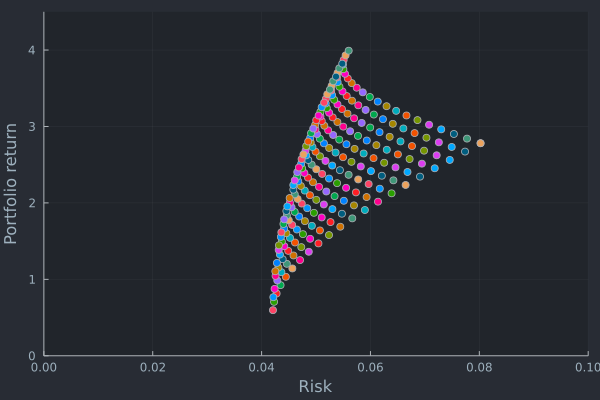

In [19]:
using StatsBase

tickerSymbol =["BTC-USD" , "ETH-USD" , "XRP-USD"]

function Return(ticker) #Returns array contaning daily return
    return_ticker=[]
    for i in 2:size(df3)[1]
        push!(return_ticker,df3[i,Symbol(ticker)]/df3[i-1,Symbol(ticker)]-1)
    end 
    return return_ticker
end

function CumulativeReturn(ticker) #Returns array containing cululative return
    CR=1
    for i in 2:size(df3)[1]
        CR*=(df3[i,Symbol(ticker)]/df3[i-1,Symbol(ticker)])
    end 
    return CR-1
end

r_BTC=Return("BTC-USD")
r_ETH=Return("ETH-USD")
r_XRP=Return("XRP-USD")
c_BTC=CumulativeReturn("BTC-USD")
c_ETH=CumulativeReturn("ETH-USD")
c_XRP=CumulativeReturn("XRP-USD")

Covarient_Mat=[[var(r_BTC)  cov(r_BTC,r_ETH) cov(r_BTC,r_XRP) ] ;
                [ cov(r_ETH,r_BTC) var(r_ETH)  cov(r_ETH,r_XRP)];
                [cov(r_XRP,r_BTC)  cov(r_XRP,r_ETH)  var(r_XRP)] ]

Risk_free_rate=0.02
max_sharpie=0

#plot
Portfolio_varience=([0  0 1]*Covarient_Mat *[0 0 1]')[1]   
Portfolio_return=([0 0 1]* [c_BTC,c_ETH,c_XRP] )
p=Plots.plot([sqrt( Portfolio_varience)],[Portfolio_return],seriestype=:scatter,label=false)

for i ∈ range(0 , step=0.05 , stop=1)
    for j ∈range(0, step=0.05,stop=1-i)
        Portfolio_varience=([i  j (round( 1-(i+j) ;digits=2))]*Covarient_Mat *[i  j (round( 1-(i+j) ;digits=2))]')[1]   #volatility =std =sqrt(variance)
        Portfolio_return=([i  j (round( 1-(i+j) ;digits=2))]* [c_BTC,c_ETH,c_XRP] )
        Plots.plot!(p,[sqrt(Portfolio_varience)],[Portfolio_return],seriestype=:scatter,label=false) 
        Sh=(Portfolio_return[1]-Risk_free_rate)/sqrt(Portfolio_varience[1]) #to find max shrpe ratio
        if Sh>max_sharpie
            max_sharpie=Sh
            global best_weights=[i  j (round( 1-(i+j) ;digits=2))]
        end
    end
end

xlabel!("Risk")
ylabel!("Portfolio return")
println("Best weights are BTC:$(best_weights[1]) ,ETH:$(best_weights[2]), XRP:$(best_weights[3])")
xlims!(0,0.1)
ylims!(0,4.5)
p

Question4:

In [4]:
df4=CSV.read("D:\\physics\\data science\\project 2\\Data_Bitcoin.CSV",DataFrame)

,Date,BTC-USD
,Date,Float64
1,2021-04-30,57750.2
2,2021-05-01,57828.1
3,2021-05-02,56631.1
4,2021-05-03,57200.3
5,2021-05-04,53333.5
6,2021-05-05,57424.0
7,2021-05-06,56396.5
8,2021-05-07,57356.4
9,2021-05-08,58803.8


In [45]:
function create_average(days)
    avg=[mean(df4[i-days:i,Symbol("BTC-USD")]) for i ∈ 101:size(df4)[1]]
    return avg
end
df4.Dates = Date.(df4.Date)

function calculate_Buy_Sell(days_long,days_short,transaction_cost,Print)
    long_avg=create_average(days_long)   
    short_avg=create_average(days_short)
    buy=[]
    sell=[]
    old =(long_avg[1]<short_avg[1]) ? "buy" : "sell"
    signals=[old]
    close=[df4[101,Symbol("BTC-USD")]]
    for i ∈1:size(long_avg)[1]
        current=(long_avg[i]*((100+transaction_cost)/100)<(short_avg[i])) ? "buy" : "sell"
        if current!=old
            if current=="buy"
                push!(buy,df4.Dates[101:end][i])
                push!(signals,"buy")
                push!(close,df4[100+i,Symbol("BTC-USD")]*((100+transaction_cost)/100))
            else
                push!(sell,df4.Dates[101:end][i])
                push!(signals,"sell")
                push!(close,df4[100+i,Symbol("BTC-USD")])
            end
            old=current
        end
    end

    profit_r=1
    for i∈ 2:size(close)[1]
        if signals[i]=="buy"
            profit_r*=close[i-1]/close[i]
        else
            profit_r*=close[i]/close[i-1]
        end
    end
    profit_r-=1 #cumulaive return

    if Print==true
        println("we have $(size(buy)[1]) buy signals in $([buy[i] for i ∈1:size(buy)[1]])")
        println("we have $(size(sell)[1]) sell signals in $([sell[i] for i ∈1:size(sell)[1]])")
    end

    return profit_r
end

max=0
for i ∈ range(5 , step=5 , stop=95)
    for j ∈range(i+5, step=5,stop=100)
        p = calculate_Buy_Sell(j,i,0,false)
        if p>max
            max = p #max cumulaive return
            global set=(i,j) 
        end  
    end
end
println("maximum cumulaive return is $(max) for shorter-term moving average days=$(set[1]) and longer-term moving average days=$(set[2])")

maximum cumulaive return is 0.9008856652848745 for shorter-term moving average days=45 and longer-term moving average days=60


we have 2 buy signals in [Date("2021-12-08"), Date("2022-04-01")]
we have 3 sell signals in [Date("2021-08-10"), Date("2022-03-13"), Date("2022-04-08")]


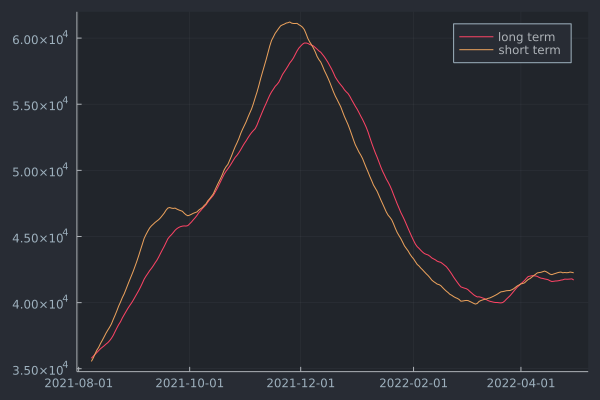

In [50]:
#with no transaction cost
long_avg=long_term_average(60)   
short_avg=long_term_average(45)

calculate_Buy_Sell(45,60,0,true)
Plots.plot(df4.Dates[days_long+1:end],long_avg,label="long term")
Plots.plot!(df4.Dates[days_long+1:end],short_avg,label="short term")

In [47]:
#with transaction cost

max=0
for i ∈ range(5 , step=5 , stop=95)
    for j ∈range(i+5, step=5,stop=100)
        p = calculate_Buy_Sell(j,i,5,false)
        if p>max
            max = p #max cumulaive return
            global set=(i,j) 
        end  
    end
end
println("maximum cumulaive return is $(max) for shorter-term moving average days=$(set[1]) and longer-term moving average days=$(set[2])")

maximum cumulaive return is 0.49375310825581376 for shorter-term moving average days=75 and longer-term moving average days=100


we have 1 buy signals in [Date("2022-01-21")]
we have 2 sell signals in [Date("2021-08-15"), Date("2022-03-09")]


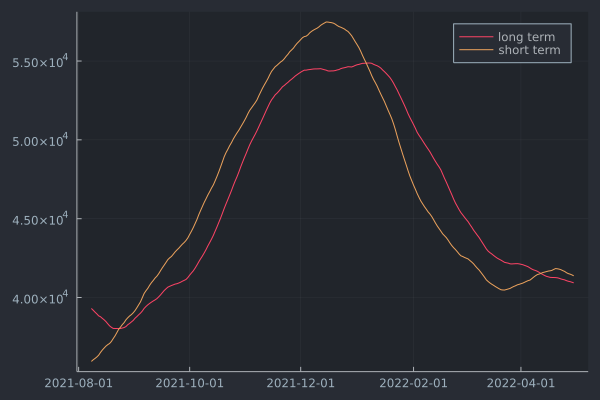

In [53]:
long_avg=long_term_average(100)   
short_avg=long_term_average(75)

calculate_Buy_Sell(75,100,5,true)
Plots.plot(df4.Dates[days_long+1:end],long_avg,label="long term")
Plots.plot!(df4.Dates[days_long+1:end],short_avg,label="short term")

Question5:

In [58]:
function isPrime(n)
    if n<=1 || (n!=floor(n)) #checks whether the input number is "Natural" and "greater than one"
        return "is not prime"
    end
    for i ∈2:Int(n)-1 
        if n % i==0 #checks whether it is not a product of two smaller natural numbers
            return "is not prime"
        end
    end
    return "is prime"
end
            
isPrime(11.0)

"is prime"

Question6:

In [59]:
df6=CSV.read("D:\\physics\\data science\\project 2\\Data_3_year.CSV",DataFrame) #start='2019-05-01', end='2022-05-01'

,Date,BTC-USD,ETH-USD,XRP-USD,ADA-USD,DOGE-USD
,Date,Float64,Float64,Float64,Float64,Float64
1,2019-04-30,5350.73,162.166,0.309476,0.070346,0.002513
2,2019-05-01,5402.7,160.818,0.304696,0.069014,0.002521
3,2019-05-02,5505.28,162.123,0.303239,0.068579,0.002611
4,2019-05-03,5768.29,167.952,0.308222,0.069858,0.002721
5,2019-05-04,5831.17,164.027,0.304552,0.06688,0.00268
6,2019-05-05,5795.71,163.451,0.302342,0.066146,0.002653
7,2019-05-06,5746.81,172.653,0.302389,0.06678,0.002542
8,2019-05-07,5829.5,169.799,0.299684,0.064036,0.002536
9,2019-05-08,5982.46,170.948,0.300721,0.064606,0.002537


In [63]:
tickerSymbol =["BTC-USD" , "ETH-USD" , "XRP-USD" , "ADA-USD" , "DOGE-USD"]

df6.Dates = Date.(df6.Date)
function Best_Trade_day(ticker) #Returns array contaning daily return
    return_ticker=[]
    for i in 2:size(df6)[1]
        push!(return_ticker,df6[i,Symbol(ticker)]/df6[i-1,Symbol(ticker)]-1)
    end 
    println("best trade day for $(ticker) is $(df6.Dates[argmax(return_ticker)+1])")
    #Plots.plot(df6.Dates[2:end],return_ticker)
end

function Best_trade_month(ticker)
    month_return=[]
    months=[]
    years=[]
    month=1
    for day ∈ 2:size(df6.Dates[2:end])[1]
        if Dates.month(Date.(df6.Date)[day])==Dates.month(Date.(df6.Date)[day-1])
            month*=(df6[day,Symbol(ticker)]/df6[day-1,Symbol(ticker)])
        else
            push!(month_return,month-1)
            push!(years,Dates.year(Date.(df6.Date)[day-1]))
            push!(months,Dates.month(Date.(df6.Date)[day-1]))
            month=df6[day,Symbol(ticker)]/df6[day-1,Symbol(ticker)]
        end 
    end
    best=Date(years[argmax(month_return)],months[argmax(month_return)])
    println("best trade month for $(ticker) is $(monthname(best)) of $(years[argmax(month_return)]) with a cumulative return of $(maximum(month_return))")
end


for t in tickerSymbol
    Best_Trade_day(t)
    Best_trade_month(t)
end

best trade day for BTC-USD is 2021-02-08
best trade month for BTC-USD is May of 2019 with a cumulative return of 0.6024930171574248
best trade day for ETH-USD is 2021-01-03
best trade month for ETH-USD is January of 2021 with a cumulative return of 0.7822989102321602
best trade day for XRP-USD is 2021-01-30
best trade month for XRP-USD is April of 2021 with a cumulative return of 1.7735842119235667
best trade day for ADA-USD is 2021-02-10
best trade month for ADA-USD is February of 2021 with a cumulative return of 2.7925967453496363
best trade day for DOGE-USD is 2021-01-28
best trade month for DOGE-USD is January of 2021 with a cumulative return of 6.944468347463301


In [65]:
function mixed_Best_day()
    return_ticker=[]
    weights=[0.2 0.2 0.2 0.2 0.2] #suppose we have equal weights
    R=0
    for i in 2:size(df6)[1]
        for t in 1:5
            R+=weights[t]* (df6[i,Symbol(tickerSymbol[t])]/df6[i-1,Symbol(tickerSymbol[t])]-1) 
        end
        push!(return_ticker,R)
        R=0
    end 
    println("best trade day for weighs $(weights) is $(df6.Dates[argmax(return_ticker)])")
end

function mixed_Best_month()
    month_return=[]
    months=[]
    years=[]
    month=1
    month1=1
    month2=1
    month3=1
    month4=1
    month5=1
    weights=[0.2 0.2 0.2 0.2 0.2] #suppose we have equal weights
    for day ∈ 2:size(df6.Dates[2:end])[1]
        if Dates.month(Date.(df6.Date)[day])==Dates.month(Date.(df6.Date)[day-1])
            month1*=(df6[day,Symbol("BTC-USD")]/df6[day-1,Symbol("BTC-USD")])
            month2*=(df6[day,Symbol("ETH-USD")]/df6[day-1,Symbol("ETH-USD")])
            month3*=(df6[day,Symbol("XRP-USD")]/df6[day-1,Symbol("XRP-USD")])
            month4*=(df6[day,Symbol("ADA-USD")]/df6[day-1,Symbol("ADA-USD")])
            month5*=(df6[day,Symbol("DOGE-USD")]/df6[day-1,Symbol("DOGE-USD")])
        else
            month=weights[1]*(month1-1)+weights[2]*(month2-1)+weights[3]*(month3-1)+weights[4]*(month4-1)+weights[5]*(month5-1)
            push!(month_return , month)
            push!(years,Dates.year(Date.(df6.Date)[day]))
            push!(months,Dates.month(Date.(df6.Date)[day]))
            month=1
            month1=1
            month2=1
            month3=1
            month4=1
            month5=1
        end 
    end
    best=Date(years[argmax(month_return)],months[argmax(month_return)])
    println("best trade month for weighs $(weights) is $(monthname(best)) of $(years[argmax(month_return)]) with a cumulative return of $(maximum(month_return))")
end

mixed_Best_day()
mixed_Best_month()

best trade day for weighs [0.2 0.2 0.2 0.2 0.2] is 2021-01-27
best trade month for weighs [0.2 0.2 0.2 0.2 0.2] is February of 2021 with a cumulative return of 1.7021815586111306


Question7:

In [66]:
using StatsBase
choices_names=["rock","paper","scissor"]
choices_num=[1,2,3]
weight1=[1,1,1]
weight2=[1,2,3]
your_score=0
cmp_score=0

function WhoWins(you,computer)
    if you==computer
        your_score+=0
    elseif ((you-computer)==1) || ((you-computer)==-2)
        global your_score+=1
    else
        global cmp_score+=1
    end
end

for i ∈1:5
    display("Round $i")
    display("Do you choose 1:rock, 2:paper or 3:scissor?")
    you=parse(Int64, readline())
    display("your choice : $(choices_names[you])")
    computer=sample(choices_num,Weights(weight1))
    display("computers choice : $(choices_names[computer])")
    WhoWins(you,computer)
end

println("your score : $your_score , computer score : $cmp_score")

if your_score>cmp_score
    println("You Win!")
elseif your_score<cmp_score
    println("Computer Wins")
else
    println("It's a draw")
end


"Round 1"

"Do you choose 1:rock, 2:paper or 3:scissor?"

"your choice : rock"

"computers choice : paper"

"Round 2"

...

"Round 5"

"Do you choose 1:rock, 2:paper or 3:scissor?"

"your choice : rock"

"computers choice : paper"

your score : 1 , computer score : 4
Computer Wins


In [34]:
algorithms_score=0
computers_score=0

function WhoWins(algorithm,computer)
    if algorithm==computer
    elseif ((algorithm-computer)==1) || ((algorithm-computer)==-2)
        global algorithms_score+=1
    else
        global computers_score+=1
    end
end

for i ∈1:1000
    algoritm=sample(choices_num,Weights(weight2))
    computer=sample(choices_num,Weights(weight1))
    WhoWins(algoritm,computer)
end

println("your score : $algorithms_score , comp score : $computers_score")

if algorithms_score>computers_score
    println("You Win!")
elseif algorithms_score<computers_score
    println("Computer Wins")
else
    println("It's a draw")
end
    

your score : 346 , comp score : 315
You Win!


the second algorithm is the winner!